Has it become more dangerous to be a pedestrian involved in a traffic accident in Germany?


In [71]:
import matplotlib.pyplot as plt

import fetch_data as fd

In [72]:
REPORT_YEARS = [2021, 2022, 2023, 2024]
report_dict = fd.get_dfs(REPORT_YEARS)

We begin by reporting the total number of accidents involving pedestrians for each year


In [73]:
ped_accident_totals: dict[int, int] = {}

for year in REPORT_YEARS:
    df_yr = report_dict[year]
    ped_accident_totals[year] = df_yr[(df_yr["IstFuss"] == 1)].shape[0]

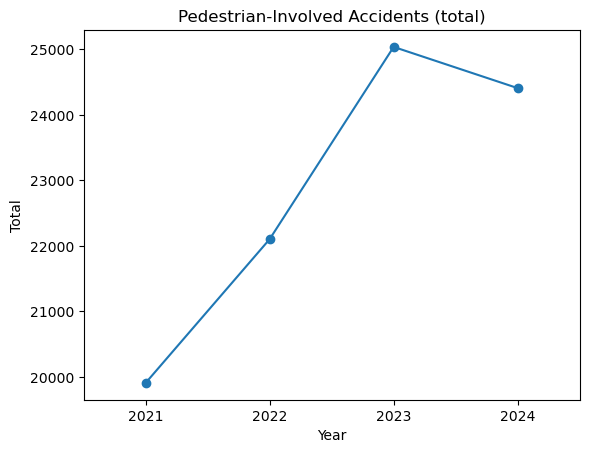

In [89]:
plt.plot(ped_accident_totals.keys(), ped_accident_totals.values(), marker="o")  # type: ignore
plt.title("Pedestrian-Involved Accidents (total)")  # type: ignore
plt.xlabel("Year")  # type: ignore
plt.ylabel("Total")  # type: ignore
plt.xlim(2020.5, 2024.5)  # type: ignore
plt.xticks(list(ped_accident_totals.keys()))  # type: ignore
plt.show()  # type: ignore

We note that there is a drastic uptick in the total number of accidents involving pedestrians. However, this could be a bump from exiting the 2020-2021 lock down era of covid ending. We analyze the number of accidents involving pedestrians as a proportion of the total accidents below.


In [75]:
ped_accident_prop: dict[int, float] = {}

for year in REPORT_YEARS:
    df_yr = report_dict[year]
    total_acc = df_yr.shape[0]
    total_acc_ped = df_yr[(df_yr["IstFuss"] == 1)].shape[0]
    ped_accident_prop[year] = total_acc_ped / total_acc if total_acc > 0 else 0

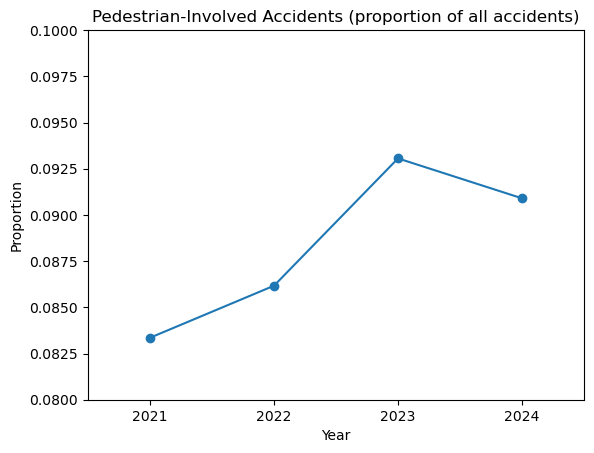

In [91]:
plt.plot(ped_accident_prop.keys(), ped_accident_prop.values(), marker="o")  # type: ignore
plt.title("Pedestrian-Involved Accidents (proportion of all accidents)")  # type: ignore
plt.xlabel("Year")  # type: ignore
plt.ylabel("Proportion")  # type: ignore
plt.ylim(0.08, 0.1)  # type: ignore
plt.xlim(2020.5, 2024.5)  # type: ignore
plt.xticks(list(ped_accident_prop.keys()))  # type: ignore
plt.show()  # type: ignore

In [77]:
prop_2021 = ped_accident_prop[2021] * 100
prop_2023 = ped_accident_prop[2023] * 100
print(f"Lowest Proportion: {prop_2021:0.1f}%, Highest Proportion: {prop_2023:0.1f}%")

Lowest Proportion: 8.3%, Highest Proportion: 9.3%


In [78]:
pct_change = (prop_2023 - prop_2021) / prop_2021 * 100
print(f"Percentage Change: {pct_change:0.1f}%")

Percentage Change: 11.6%


In [79]:
pct_2024 = ped_accident_prop[2024] * 100
pct_change = (pct_2024 - prop_2021) / prop_2021 * 100
print(f"Percentage Change: {pct_change:0.1f}%")

Percentage Change: 9.1%


Unlike with bicycle-involved accidents, where the proportion of accidents involving bicycles is relatively constant year to year, we see a 1% increase in the share of pedestrian-involved accidents between 2021 and 2023. This is equivalent to an 11.6% change in the same timespan. While the proportion of pedestrian-involved accidents fell in 2024, we still see a 9.1% increase in the years 2021-2024.


In [80]:
ped_accident_serious_fatal_totals: dict[int, int] = {}

for year in REPORT_YEARS:
    df_yr = report_dict[year]
    ped_accident_serious_fatal_totals[year] = df_yr[
        (df_yr["IstFuss"] == 1) & (df_yr["UKATEGORIE"] < 3)
    ].shape[0]

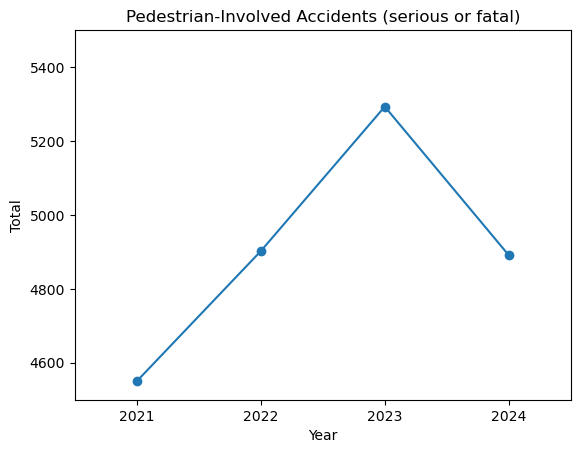

In [92]:
plt.plot(  # type: ignore
    ped_accident_serious_fatal_totals.keys(),  # type: ignore
    ped_accident_serious_fatal_totals.values(),  # type: ignore
    marker="o",
)
plt.title("Pedestrian-Involved Accidents (serious or fatal)")  # type: ignore
plt.xlabel("Year")  # type: ignore
plt.ylabel("Total")  # type: ignore
plt.xlim(2020.5, 2024.5)  # type: ignore
plt.ylim(4500, 5500)  # type: ignore
plt.xticks(REPORT_YEARS)  # type: ignore
plt.show()  # type: ignore

Again, this seems like a sharp increase but is there really an uptick in the proportion of pedestrian accidents that are serious or fatal?


In [82]:
ped_accident_serious_fatal_prop: dict[int, float] = {
    year: ped_accident_serious_fatal_totals[year] / ped_accident_totals[year]
    for year in REPORT_YEARS
}

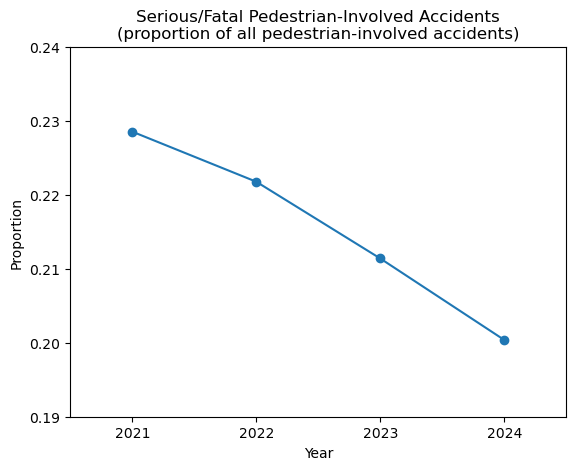

In [94]:
plt.plot(ped_accident_serious_fatal_prop.keys(), ped_accident_serious_fatal_prop.values(), marker="o")  # type: ignore
plt.title("Serious/Fatal Pedestrian-Involved Accidents\n(proportion of all pedestrian-involved accidents)")  # type: ignore
plt.xlabel("Year")  # type: ignore
plt.ylabel("Proportion")  # type: ignore
plt.ylim(0.19, 0.24)  # type: ignore
plt.xlim(2020.5, 2024.5)  # type: ignore
plt.xticks(list(ped_accident_serious_fatal_prop.keys()))  # type: ignore
plt.show()  # type: ignore

In [84]:
prop_2021 = ped_accident_serious_fatal_prop[2021] * 100
prop_2024 = ped_accident_serious_fatal_prop[2024] * 100

pct_change = (prop_2024 - prop_2021) / prop_2021 * 100
print(f"Percentage Change: {pct_change:0.1f}%")

Percentage Change: -12.3%


What we actually find is that the proportion of accidents involving pedestrians that result in serious for fatal injury has decreased by 12.3% over the last 4 years. Breaking down the categories further, we find the following:


In [85]:
ped_accident_serious_prop: dict[int, float] = {}

for year in REPORT_YEARS:
    df_yr = report_dict[year]
    total_acc = ped_accident_totals[year]
    total_acc_ped_serious = df_yr[
        (df_yr["IstFuss"] == 1) & (df_yr["UKATEGORIE"] == 2)
    ].shape[0]
    ped_accident_serious_prop[year] = (
        total_acc_ped_serious / total_acc if total_acc > 0 else 0
    )

In [86]:
ped_accident_fatal_prop: dict[int, float] = {}

for year in REPORT_YEARS:
    df_yr = report_dict[year]
    total_acc = ped_accident_totals[year]
    total_acc_ped_fatal = df_yr[
        (df_yr["IstFuss"] == 1) & (df_yr["UKATEGORIE"] == 1)
    ].shape[0]
    ped_accident_fatal_prop[year] = (
        total_acc_ped_fatal / total_acc if total_acc > 0 else 0
    )

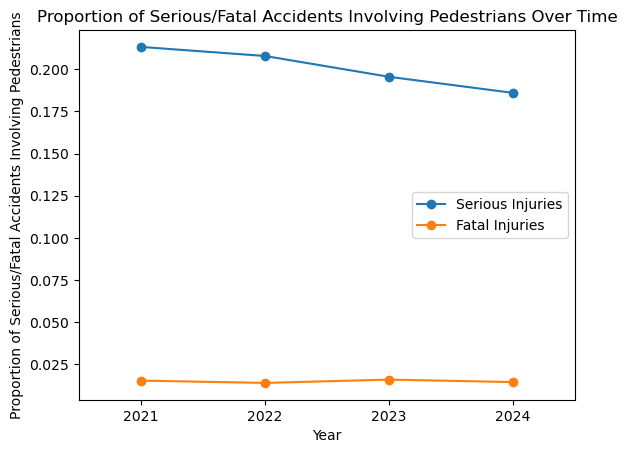

In [ ]:
plt.plot(  # type: ignore
    ped_accident_serious_prop.keys(),  # type: ignore
    ped_accident_serious_prop.values(),  # type: ignore
    marker="o",
    label="Serious Injuries",
)
plt.plot(  # type: ignore
    ped_accident_fatal_prop.keys(),  # type: ignore
    ped_accident_fatal_prop.values(),  # type: ignore
    marker="o",
    label="Fatal Injuries",
)

plt.title("Serious/Fatal Pedestrian-Involved Accidents\n(proportion of all pedestrian-involved accidents)")  # type: ignore
plt.xlabel("Year")  # type: ignore
plt.ylabel("Proportion")  # type: ignore
plt.xlim(2020.5, 2024.5)  # type: ignore
plt.xticks(list(ped_accident_serious_fatal_prop.keys()))  # type: ignore
plt.legend()  # type: ignore
plt.show()  # type: ignore

In [88]:
pct_change_serious = (
    (ped_accident_serious_prop[2024] - ped_accident_serious_prop[2021])
    / ped_accident_serious_prop[2021]
    * 100
)
pct_change_fatal = (
    (ped_accident_fatal_prop[2024] - ped_accident_fatal_prop[2021])
    / ped_accident_fatal_prop[2021]
    * 100
)

print(f"Percentage Change Serious Injuries: {pct_change_serious:0.1f}%")
print(f"Percentage Change Fatal Injuries: {pct_change_fatal:0.1f}%")

Percentage Change Serious Injuries: -12.8%
Percentage Change Fatal Injuries: -5.8%


While the total number of accidents increased, we find that the proportion of pedestrian-involved accidents that resulted in a serious injury has decreased by 12.8%. Similarly, the proportion of pedestrian-involved accidents that resulted in a fatality has decreased by 5.8%.

While we cannot make any conclusions on the likelihood of being in an accident based on this data, should there be a pedestrian-involved accident, it is less likely that there will be a serious or fatal injury compared to just 4 years ago.


## Question

Can we create a baysian model to try to predict the severity of pedestrian related accidents? What is likely to be the key indicators? Geo location, time of day, weather? How can we treat a geolocation as a single data point (transformation)?
